# GridSTAGE &rarr; ANDES REGCV2 Playback Prototype

This notebook replays **one pre-generated GridSTAGE disturbance profile**
(voltage and frequency at a single PMU bus) into an **ANDES `REGCV2`
grid-forming inverter** using the `PLBVFU1` playback generator + `TimeSeries`
mechanism, and recovers its inertia (`H`) and damping/droop (`D`) from its
own internal control-loop signals using the on-line estimators of:

> Muyang Liu, Junru Chen, Federico Milano, "On-Line Inertia Estimation for
> Synchronous and Non-Synchronous Devices," *IEEE Transactions on Power
> Systems*, vol. 36, no. 3, May 2021.

The disturbance data is generated by GridSTAGE (Grid Spatio-Temporal
Adversarial Scenario GEneration framework), built on the Power System
Toolbox:
> Joe H. Chow, Kwok W. Cheung, "A toolbox for power system dynamics and
> control engineering education and research," *IEEE Trans. Power
> Systems*, 7(4), 1992.
> Jiangmeng Zhang, Alejandro D. Dominguez-Garcia, "Augmenting the power
> system toolbox: Enabling automatic generation control and providing a
> platform for cyber security analysis," NAPS 2016.
> Nandanoori, Kundu, Pal, Agarwal, Choudhury, "Model-Agnostic Algorithm for
> Real-Time Attack Identification in Power Grid using Koopman Modes," IEEE
> ICCCCTSG, 2020.

**Scope of this prototype:** one GridSTAGE scenario, one bus, one REGCV2
inverter, one V/f playback profile, one active-power response. No parameter
sweeps, no closed-loop grid feedback &mdash; see Section 9/13 for why.

## Framing and Value Proposition

This notebook targets a **different real-world use case** than a
system-operator, black-box, PMU-only estimation setup (that's the companion
`wscc9_vsg_inertia_noise_delay.ipynb` notebook, which reproduces Liu et
al.'s own idealized-VSG case study using only externally-measurable
terminal quantities). Here, the intended user is an **inverter OEM, asset
owner, or aggregator** who *does* have access to their own device's
internal control-loop states -- because they built or operate the
controller -- and wants to self-monitor, verify grid-code compliance, or
tune adaptive control using the device's own true response to a realistic
disturbance. That access is exactly what a real embedded controller or
manufacturer telemetry API already exposes; it does not require solving
the terminal-only black-box problem the companion notebook addresses.

**A key finding, complementary to the companion notebook:** the Frequency
Divider Formula (Eq. 9), the terminal-only reconstruction step the
companion notebook validates for an idealized VSG (`GENCLS`, R2=0.99),
**does not work for REGCV2** -- a realistic multi-loop grid-forming
converter with an actively-regulated terminal voltage (FDF R2 ~ 0.5-0.8
regardless of tuning; see the footnote in Section 16). That is why this
notebook uses REGCV2's internal signals directly instead of attempting FDF
reconstruction. Together, the two notebooks bound the method's
applicability along a **device-architecture axis**: it transfers cleanly
to idealized swing-equation-behind-impedance devices, but not to realistic
actively-controlled converters -- a distinction the original paper does not
test, since it only considers synchronous generators, an idealized VSG, and
a DFIG wind turbine.


## Setup

**Requirements:** Python >= 3.11, and:
```
pip install andes
```
This pulls in every other Python dependency this notebook needs (`numpy`,
`pandas`, `scipy`, `matplotlib`, etc.) automatically. ANDES is open source:
https://github.com/curent/andes. This notebook was built and tested against
`andes==2.0.0`.

**Data/files needed -- unlike the companion notebook, this one is *not*
self-contained.** Section 1/2 below look for two sibling folders (walking
up from wherever this notebook is run, so a subfolder is fine too):

```
some_folder/
├── andes/                      <- any folder named "andes" satisfies an
│                                   internal safety check; does not need
│                                   real content (ANDES itself comes from
│                                   `pip install andes` above, not this
│                                   folder)
├── GridSTAGE/
│   └── Data/IEEE68busSystem/SystematicLoadChanges/scenario1/
│       ├── PMUData.mat          <- the file actually read (~6 MB)
│       └── ScenarioDescription.txt
└── andes_gridstage_regf2_prototype.ipynb   <- this notebook
```

Get the GridSTAGE data from https://github.com/pnnl/GridSTAGE (Pacific
Northwest National Laboratory) -- clone the full repo, or just recreate the
`Data/IEEE68busSystem/SystematicLoadChanges/scenario1/` path with those two
files if you only want to move the ~6 MB actually needed rather than the
full ~200 MB repository.

**Kernel:** this notebook's saved kernel is named `gridstage`, a local
conda environment name. If you don't have an environment by that name,
just select any Python >=3.11 kernel/environment that has `andes`
installed when you open it -- the name itself has no other effect.


## 1. Imports and Configuration

Standard scientific Python stack, plus `andes` (installed in editable mode
from the local `andes/` clone in this same parent folder) and `scipy.io` for
reading the GridSTAGE `.mat` file. We also locate the `GridSTAGE` and `andes`
folders relative to this notebook so it runs regardless of the current
working directory, as long as both repos remain siblings.


In [1]:
import re
import sys
import time
import logging
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

# --- Gotcha specific to this folder layout ---
# This notebook lives next to a folder literally named `andes/` (the cloned
# ANDES repo). Jupyter puts the notebook's working directory on `sys.path`,
# and since that directory itself contains an `andes` subfolder with no
# `__init__.py` at its root, Python's import system can resolve `import
# andes` as an empty PEP 420 namespace package (shadowing the real,
# pip-installed editable package) before it ever reaches the proper
# installed package. Guard against that explicitly rather than silently
# getting a broken `andes` with no attributes.
sys.path = [p for p in sys.path if p not in ('', str(Path.cwd()))]
for _mod in [m for m in list(sys.modules) if m == 'andes' or m.startswith('andes.')]:
    del sys.modules[_mod]

import andes

if getattr(andes, '__file__', None) is None:
    raise ImportError(
        'andes resolved as a namespace package (no __file__) -- it is being '
        'shadowed by a same-named folder on sys.path. Restart the kernel from '
        'a different working directory, or check the editable install.'
    )

# Keep ANDES's normally-verbose INFO logging out of the notebook output;
# warnings/errors still show.
logging.getLogger('andes').setLevel(logging.WARNING)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 3.5)

print('andes file   :', andes.__file__)
print('andes version:', andes.__version__ if hasattr(andes, '__version__') else '(dev, see andes/_version.py)')


andes file   : /Users/mingchen/Sources/tools/grid/andes/andes/__init__.py
andes version: 2.0.0


In [2]:
# Locate the GridSTAGE and andes folders as siblings of this notebook's
# working directory (walk up if the notebook is launched from elsewhere).
BASE_DIR = Path.cwd()
for candidate in [BASE_DIR, *BASE_DIR.parents]:
    if (candidate / 'GridSTAGE').exists() and (candidate / 'andes').exists():
        BASE_DIR = candidate
        break

GRIDSTAGE_DIR = BASE_DIR / 'GridSTAGE'
ANDES_DIR = BASE_DIR / 'andes'

assert GRIDSTAGE_DIR.exists(), f'GridSTAGE folder not found near {BASE_DIR}'
assert ANDES_DIR.exists(), f'andes folder not found near {BASE_DIR}'

print('BASE_DIR      :', BASE_DIR)
print('GRIDSTAGE_DIR :', GRIDSTAGE_DIR)
print('ANDES_DIR     :', ANDES_DIR)


BASE_DIR      : /Users/mingchen/Sources/tools/grid
GRIDSTAGE_DIR : /Users/mingchen/Sources/tools/grid/GridSTAGE
ANDES_DIR     : /Users/mingchen/Sources/tools/grid/andes


## 2. Locate GridSTAGE Scenario

We use the simple systematic load-change scenario
`IEEE68busSystem/SystematicLoadChanges/scenario1`, which contains
`PMUData.mat` and a human-readable `ScenarioDescription.txt`. We print the
description up front so it's clear exactly what event is being replayed
before any data wrangling happens.


In [3]:
SCENARIO_DIR = GRIDSTAGE_DIR / 'Data' / 'IEEE68busSystem' / 'SystematicLoadChanges' / 'scenario1'
assert SCENARIO_DIR.exists(), f'Scenario folder not found: {SCENARIO_DIR}'

print('Scenario folder contents:')
for f in sorted(SCENARIO_DIR.iterdir()):
    print(' ', f.name)


Scenario folder contents:
  PMUData.mat
  PMUData_SNR.mat
  PMU_F.jpg
  PMU_V.jpg
  ScenarioDescription.txt


In [4]:
DESC_PATH = SCENARIO_DIR / 'ScenarioDescription.txt'
desc_text = DESC_PATH.read_text()
print(desc_text)


IEEE 68 bus system
Load changes: YES 
Start time of load changes: 1.00 
End time of load changes: 1.25 
Load buses where the load changes: 20 
Load buses where the load changes: 23 
Load buses where the load changes: 25 
Load buses where the load changes: 36 
Load buses where the load changes: 41 
Load buses where the load changes: 42 
Magnitude of load changes: 14.90 
Magnitude of load changes: 11.34 
Magnitude of load changes: -9.42 
Magnitude of load changes: 7.11 
Magnitude of load changes: 17.61 
Magnitude of load changes: 20.65 
Power system stabilizer (PSS): NO 
Automatic generation control (AGC): NO 
Generator Type (at all generators): Subtransient round rotor 
 
Reproducing the sw_con variable information to understand the step time(s), simulation time(s), and event description. 

sw_con = 
0.00 0 0 0 0 0 0.010 
0.05 1 2 0 0 6 0.010 
0.10 0 0 0 0 0 0.010 
0.20 0 0 0 0 0 0.010 
0.50 0 0 0 0 0 0.010 
30.00 0 0 0 0 0 0.010 

 
PMU locations = 
1 	2 	3 	4 	5 	6 	7 	8 	9 	10 	11 	1

In [5]:
# Pull out the disturbance start/end times so later cells don't hardcode them.
m_start = re.search(r'Start time of load changes:\s*([\d.]+)', desc_text)
m_end = re.search(r'End time of load changes:\s*([\d.]+)', desc_text)
DIST_START_ORIG = float(m_start.group(1))
DIST_END_ORIG = float(m_end.group(1))

print(f'Disturbance interval (original GridSTAGE time axis): '
      f'{DIST_START_ORIG:.3f} s -> {DIST_END_ORIG:.3f} s')


Disturbance interval (original GridSTAGE time axis): 1.000 s -> 1.250 s


## 3. Inspect MATLAB Structure

We load `PMUData.mat` with `scipy.io.loadmat(..., squeeze_me=True,
struct_as_record=False)`. This turns MATLAB structs into Python objects with
a `_fieldnames` attribute rather than leaving everything as awkward
`[[x]]`-nested record arrays.

Note: for *this particular* file the top-level data is **not** nested under a
`DMU` key (that nesting shows up in other GridSTAGE files/scenarios) &mdash;
instead the top-level keys are `PMU`, `t`, `pelect`, `fmeas_con`, etc., with
`PMU` itself being a struct of arrays. Rather than assuming either layout, we
inspect it explicitly and use a small generic helper that can unwrap
MATLAB structs / singleton dimensions regardless of nesting depth, so the
same code is robust if pointed at a differently-shaped GridSTAGE file.


In [6]:
MAT_PATH = SCENARIO_DIR / 'PMUData.mat'
mat_data = sio.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

top_keys = [k for k in mat_data.keys() if not k.startswith('__')]
print('Top-level keys:', top_keys)


Top-level keys: ['AttackLocation', 'PMU', 'PMU_SamplingFreq', 'PMU_samples', 'SimulationTime', 'TimeStep_of_simulation', 'fmeas_con', 'pelect', 't']


In [7]:
def describe_matlab_obj(obj, name='', depth=0, max_depth=2):
    """Recursively print the shape/type of a loadmat object, unwrapping
    scipy.io mat_struct objects and object-dtype ndarrays as it goes."""
    indent = '  ' * depth
    if isinstance(obj, sio.matlab.mat_struct):
        print(f'{indent}{name}: mat_struct with fields {obj._fieldnames}')
        if depth < max_depth:
            for fn in obj._fieldnames:
                describe_matlab_obj(getattr(obj, fn), name=fn, depth=depth + 1, max_depth=max_depth)
    elif isinstance(obj, np.ndarray):
        print(f'{indent}{name}: ndarray shape={obj.shape} dtype={obj.dtype}')
        if obj.dtype == object and obj.size > 0 and depth < max_depth:
            describe_matlab_obj(obj.flat[0], name=f'{name}[0]', depth=depth + 1, max_depth=max_depth)
    else:
        print(f'{indent}{name}: {type(obj).__name__} = {obj}')


for k in top_keys:
    describe_matlab_obj(mat_data[k], name=k)
    print()


AttackLocation: ndarray shape=(0,) dtype=uint8

PMU: mat_struct with fields ['Vm', 'Va', 'f', 'fdot', 'Im', 'Ia', 'Id', 'TimeStamps']
  Vm: ndarray shape=(1500, 68) dtype=float64
  Va: ndarray shape=(1500, 68) dtype=float64
  f: ndarray shape=(1500, 68) dtype=float64
  fdot: ndarray shape=(1499, 68) dtype=float64
  Im: ndarray shape=(68,) dtype=object
    Im[0]: ndarray shape=(1500, 5) dtype=float64
  Ia: ndarray shape=(68,) dtype=object
    Ia[0]: ndarray shape=(1500, 5) dtype=float64
  Id: ndarray shape=(68,) dtype=object
    Id[0]: ndarray shape=(5,) dtype=object
  TimeStamps: ndarray shape=(1500,) dtype=float64

PMU_SamplingFreq: int = 50

PMU_samples: ndarray shape=(1500,) dtype=uint16

SimulationTime: int = 30

TimeStep_of_simulation: float = 0.01

fmeas_con: ndarray shape=(68, 3) dtype=float64

pelect: ndarray shape=(16, 3001) dtype=float64

t: ndarray shape=(3001,) dtype=float64



In [8]:
# 'PMU' is the struct of interest: one 2-D array per quantity, shaped
# (n_samples, n_buses). Confirm that explicitly.
pmu = mat_data['PMU']
print('PMU fields:', pmu._fieldnames)
for fn in pmu._fieldnames:
    v = getattr(pmu, fn)
    print(f'  {fn}: shape={getattr(v, "shape", None)} dtype={getattr(v, "dtype", None)}')


PMU fields: ['Vm', 'Va', 'f', 'fdot', 'Im', 'Ia', 'Id', 'TimeStamps']
  Vm: shape=(1500, 68) dtype=float64
  Va: shape=(1500, 68) dtype=float64
  f: shape=(1500, 68) dtype=float64
  fdot: shape=(1499, 68) dtype=float64
  Im: shape=(68,) dtype=object
  Ia: shape=(68,) dtype=object
  Id: shape=(68,) dtype=object
  TimeStamps: shape=(1500,) dtype=float64


## 4. Extract PMU Data

`PMU.Vm` and `PMU.f` are `(n_samples, n_buses)` arrays; `PMU.TimeStamps` is
the shared `(n_samples,)` time vector (sampled every ~0.02 s, i.e. 50 Hz,
matching `PMU_SamplingFreq` in the file). We pick **bus 20** (1-indexed):
it's one of the six load buses actually perturbed in this scenario
(`20, 23, 25, 36, 41, 42`), and of those six it shows the clearest combined
voltage *and* frequency deviation, making it a good single PMU to visualize.

We also pull `PMU.fdot` (ROCOF) and `PMU.Va` (voltage angle) for bus 20 since
they're available and requested as optional extras, even though only V and f
are used to drive the ANDES playback.


In [9]:
BUS_1INDEXED = 20
bus_col = BUS_1INDEXED - 1  # convert to 0-indexed column

t_pmu = pmu.TimeStamps.astype(float)
Vm_bus = pmu.Vm[:, bus_col].astype(float)
f_bus = pmu.f[:, bus_col].astype(float)
Va_bus = pmu.Va[:, bus_col].astype(float)
# fdot has one fewer sample than Vm/f/TimeStamps (it's a finite difference)
fdot_bus = pmu.fdot[:, bus_col].astype(float)

raw_df = pd.DataFrame({
    'time_s': t_pmu,
    'voltage_pu': Vm_bus,
    'frequency_hz': f_bus,
})

sampling_interval = np.median(np.diff(t_pmu))

print(f'Selected bus (1-indexed)      : {BUS_1INDEXED}')
print(f'Number of samples              : {len(raw_df)}')
print(f'Original sampling interval     : {sampling_interval:.4f} s  (~{1/sampling_interval:.1f} Hz)')
print(f'Time range                     : {raw_df.time_s.min():.3f} s -> {raw_df.time_s.max():.3f} s')
print(f'Voltage range (pu)             : {raw_df.voltage_pu.min():.4f} -> {raw_df.voltage_pu.max():.4f}')
print(f'Frequency range (Hz)           : {raw_df.frequency_hz.min():.4f} -> {raw_df.frequency_hz.max():.4f}')
print(f'Max |ROCOF| (Hz/s), this bus    : {np.max(np.abs(fdot_bus)):.4f}')


Selected bus (1-indexed)      : 20
Number of samples              : 1500
Original sampling interval     : 0.0200 s  (~50.0 Hz)
Time range                     : 0.020 s -> 30.000 s
Voltage range (pu)             : 0.9544 -> 0.9934
Frequency range (Hz)           : 59.8571 -> 60.1017
Max |ROCOF| (Hz/s), this bus    : 0.8365


## 5. Raw Disturbance Plot

Sanity-check plot of the **raw, un-interpolated** GridSTAGE samples for bus
20, before any time-shifting or resampling. The shaded band marks the
load-change interval from `ScenarioDescription.txt`.


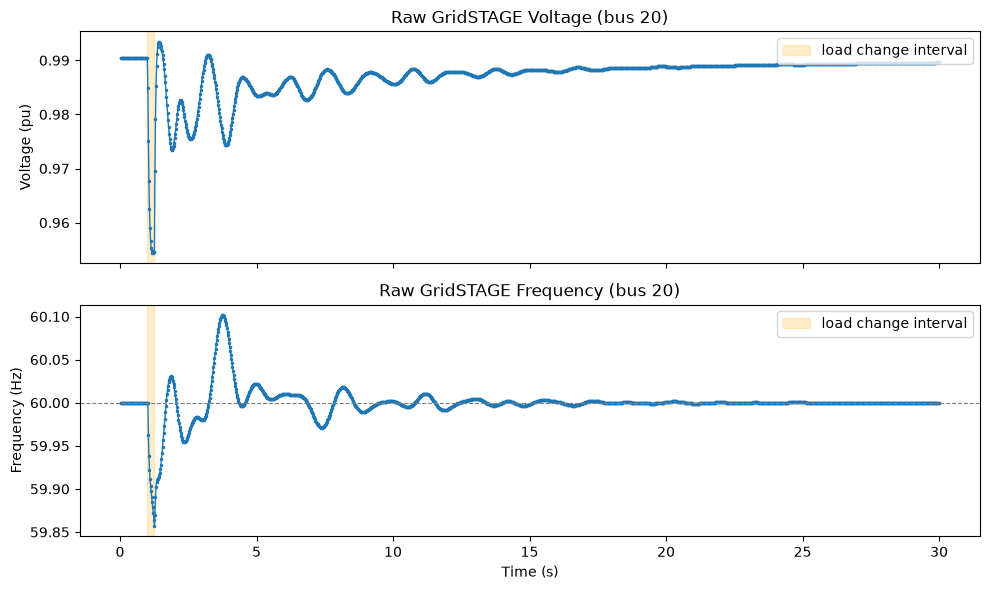

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, col, ylabel, title in [
    (axes[0], 'voltage_pu', 'Voltage (pu)', 'Raw GridSTAGE Voltage (bus 20)'),
    (axes[1], 'frequency_hz', 'Frequency (Hz)', 'Raw GridSTAGE Frequency (bus 20)'),
]:
    ax.plot(raw_df.time_s, raw_df[col], marker='.', markersize=3, linewidth=1)
    ax.axvspan(DIST_START_ORIG, DIST_END_ORIG, color='orange', alpha=0.2, label='load change interval')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right')

axes[1].axhline(60.0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 6. Normalize Time

Shift the time axis so the first GridSTAGE sample lands at `t = 0`, per the
spec (`time = time - time[0]`). We track the shift amount so the
disturbance-interval markers can be shifted consistently too.


In [11]:
t0_shift = raw_df.time_s.iloc[0]

raw_df = raw_df.assign(time_s=raw_df.time_s - t0_shift)

DIST_START_SHIFTED = DIST_START_ORIG - t0_shift
DIST_END_SHIFTED = DIST_END_ORIG - t0_shift

print(f'Time shift applied              : {t0_shift:.4f} s')
print(f'New time range                  : {raw_df.time_s.min():.3f} s -> {raw_df.time_s.max():.3f} s')
print(f'Disturbance interval (shifted)  : {DIST_START_SHIFTED:.3f} s -> {DIST_END_SHIFTED:.3f} s')


Time shift applied              : 0.0200 s
New time range                  : 0.000 s -> 29.980 s
Disturbance interval (shifted)  : 0.980 s -> 1.230 s


## 7. Interpolate to 1 ms

GridSTAGE samples at ~0.02 s; we resample onto a uniform 0.001 s grid with
plain linear interpolation (`np.interp`) &mdash; deliberately **not** a cubic
spline, to avoid manufacturing overshoot around the disturbance that isn't
in the original data.

> **Important caveat:** interpolation creates a 1 ms *numerical* time grid
> for feeding the simulator, but it does not create new physical measurement
> bandwidth. The underlying GridSTAGE observations are still ~20 ms PMU
> samples; the 1 kHz grid is a modeling convenience for ANDES, not a claim
> that we know the true waveform at 1 ms resolution.

We also add a `frequency_pu` column (`frequency_hz / 60.0`) since the ANDES
playback path needs frequency in per unit, while keeping `frequency_hz` for
plotting.


In [12]:
DT = 0.001
t_new = np.arange(raw_df.time_s.min(), raw_df.time_s.max() + DT, DT)

voltage_interp = np.interp(t_new, raw_df.time_s, raw_df.voltage_pu)
frequency_interp = np.interp(t_new, raw_df.time_s, raw_df.frequency_hz)

profile_df = pd.DataFrame({
    'time_s': t_new,
    'voltage_pu': voltage_interp,
    'frequency_hz': frequency_interp,
    'frequency_pu': frequency_interp / 60.0,
})

# --- sanity checks (Part 12) ---
assert np.all(np.diff(profile_df.time_s) > 0), 'time_s must be strictly increasing'
median_dt = np.median(np.diff(profile_df.time_s))
assert abs(median_dt - DT) < 1e-9, f'median dt {median_dt} != {DT}'
assert not profile_df.isnull().values.any(), 'NaN found in profile_df'
assert np.isfinite(profile_df.values).all(), 'non-finite values found in profile_df'
assert profile_df.frequency_hz.between(55, 65).all(), 'frequency out of plausible range'
assert profile_df.voltage_pu.between(0.5, 1.5).all(), 'voltage out of plausible pu range'

print(f'Interpolated samples : {len(profile_df)}')
print(f'Median dt             : {median_dt:.6f} s')
profile_df.head()


Interpolated samples : 29981
Median dt             : 0.001000 s


,time_s,voltage_pu,frequency_hz,frequency_pu
0,0.000,0.990432,60.0,1.0
1,0.001,0.990432,60.0,1.0
2,0.002,0.990432,60.0,1.0
3,0.003,0.990432,60.0,1.0
4,0.004,0.990432,60.0,1.0


In [13]:
CSV_PATH = BASE_DIR / 'scenario1_bus20_profile_1ms.csv'
profile_df.to_csv(CSV_PATH, index=False)
print('Saved full 1 ms interpolated profile to:', CSV_PATH)


Saved full 1 ms interpolated profile to: /Users/mingchen/Sources/tools/grid/scenario1_bus20_profile_1ms.csv


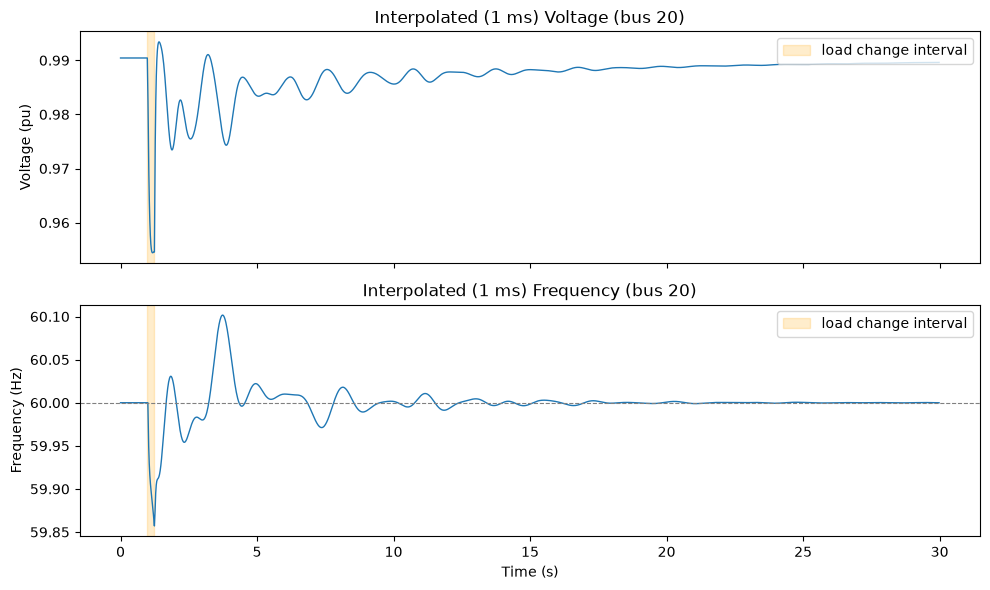

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, col, ylabel, title in [
    (axes[0], 'voltage_pu', 'Voltage (pu)', 'Interpolated (1 ms) Voltage (bus 20)'),
    (axes[1], 'frequency_hz', 'Frequency (Hz)', 'Interpolated (1 ms) Frequency (bus 20)'),
]:
    ax.plot(profile_df.time_s, profile_df[col], linewidth=1)
    ax.axvspan(DIST_START_SHIFTED, DIST_END_SHIFTED, color='orange', alpha=0.2, label='load change interval')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right')

axes[1].axhline(60.0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 8. Prepare ANDES Playback Data

ANDES's `TimeSeries` model (see `andes/models/timeseries.py`) only implements
**mode 1 ("exact time")** &mdash; `apply_interpolate()` for mode 2 raises
`NotImplementedError` in this installed version. Mode 1 works by forcing the
time-domain solver (`TDS`) to stop at *every single timestamp* supplied in
the playback file.

That "every timestamp" cost is actually **3x** the raw sample count, not 1x:
`System.store_switch_times()` (`andes/system/facade.py`) takes each
timestamp `t` from `TimeSeries.get_times()` and inserts three entries into
the forced-stop list &mdash; `t`, `t - eps`, and `t + eps` (`eps = 1e-4 s`
by default):

```python
out = np.append(out, times)
out = np.append(out, times - eps)
out = np.append(out, times + eps)
```

So our 30 s recording at 1 ms resolution is **~30,000 raw samples**, but
that becomes **~90,000 forced solver stops** (before dedup/sorting) once
this &plusmn;eps padding is added &mdash; the 90k comes from the 3x padding
factor, not from the sample count itself.

Earlier versions of this notebook windowed the input to a few seconds around
the disturbance to keep the forced-stop count manageable. But that leaves
the settling question unanswered, since the windowed run necessarily ends
before we know what the rest of the recording does. To directly check
*"does the power ever settle?"*, we instead feed ANDES the **entire 30 s
recording** at its full 1 ms resolution &mdash; the same `profile_df` built
in Section 7, unmodified, no windowing and no synthetic held tail (the real
recording itself is already close to flat by its final several seconds, so
there's no need to fabricate one).

This was measured to take **on the order of 90 seconds** of wall-clock time
for TDS in Section 11 below &mdash; slow for a prototype, but tractable for
a one-off run, and it's the only way to see the true long-horizon behavior
rather than assuming it from a short window.


In [15]:
andes_input_df = profile_df[['time_s', 'voltage_pu', 'frequency_pu', 'frequency_hz']].copy()

# Disturbance interval on this (unmodified) ANDES time axis -- identical to
# DIST_START_SHIFTED / DIST_END_SHIFTED since no windowing/re-zeroing happens here.
DIST_START_ANDES = DIST_START_SHIFTED
DIST_END_ANDES = DIST_END_SHIFTED

print(f'ANDES playback input                        : full Section 7 profile, unwindowed')
print(f'Simulation duration                         : 0 s -> {andes_input_df.time_s.iloc[-1]:.3f} s')
print(f'Number of playback rows                     : {len(andes_input_df)}')
print(f'Disturbance interval on ANDES time axis      : {DIST_START_ANDES:.3f} s -> {DIST_END_ANDES:.3f} s')


ANDES playback input                        : full Section 7 profile, unwindowed
Simulation duration                         : 0 s -> 29.980 s
Number of playback rows                     : 29981
Disturbance interval on ANDES time axis      : 0.980 s -> 1.230 s


In [16]:
# --- sanity checks on the ANDES input series ---
assert np.all(np.diff(andes_input_df.time_s) > 0), 'ANDES input time_s must be strictly increasing'
assert not andes_input_df.isnull().values.any(), 'NaN found in ANDES input'
assert np.isfinite(andes_input_df.values).all(), 'non-finite values in ANDES input'
assert andes_input_df.voltage_pu.between(0.5, 1.5).all()
assert andes_input_df.frequency_pu.between(55/60, 65/60).all()

andes_input_df.head()


,time_s,voltage_pu,frequency_pu,frequency_hz
0,0.000,0.990432,1.0,60.0
1,0.001,0.990432,1.0,60.0
2,0.002,0.990432,1.0,60.0
3,0.003,0.990432,1.0,60.0
4,0.004,0.990432,1.0,60.0


In [17]:
# Auto-generate the TimeSeries xlsx file that ANDES's TimeSeries model reads.
# Columns/sheet name follow the working pattern in
# andes/cases/ieee14/plbvf.xlsx + andes/tests/integration/test_plbvfu1.py:
# a 't' column plus one column per playback field ('V', 'f'), 'f' in per unit.
TS_XLSX_PATH = BASE_DIR / 'plbvf_gridstage_scenario1_bus20.xlsx'

ts_sheet_df = pd.DataFrame({
    't': andes_input_df.time_s,
    'V': andes_input_df.voltage_pu,
    'f': andes_input_df.frequency_pu,
})
with pd.ExcelWriter(TS_XLSX_PATH, engine='openpyxl') as writer:
    ts_sheet_df.to_excel(writer, sheet_name='PLBVF', index=False)

print('Wrote ANDES TimeSeries playback file:', TS_XLSX_PATH)


Wrote ANDES TimeSeries playback file: /Users/mingchen/Sources/tools/grid/plbvf_gridstage_scenario1_bus20.xlsx


## 9. Build ANDES + REGCV2 Case

**Architecture** (confirmed against the installed ANDES source
&mdash; `andes/models/renewable/regcv2.py`, `andes/models/renewable/regcv1.py`,
`andes/models/synchronous/plbvfu1.py`, `andes/models/timeseries.py` &mdash;
and the working example `andes/cases/ieee14/ieee14_plbvfu1.xlsx`):

```
GridSTAGE V(t), f(t)  --(TimeSeries, mode=1)-->  PLBVFU1.Vts, PLBVFU1.fts
                                                        |
                                            Bus 1 (playback "grid")
                                                        |
                                                      Line
                                                        |
                                            Bus 2 (REGCV2 point of interconnection)
                                                        |
                                                      REGCV2  -->  Pe(t)
```

This is the smallest network that lets REGCV2 experience the playback signal
&mdash; identical to the REGF2 version of this notebook, just with the
inverter model swapped:

- **Bus 1 / Slack**: the `Slack` static generator here is *replaced* at
  simulation time by `PLBVFU1` (via `PLBVFU1.gen`), which plays back the
  GridSTAGE V/f profile as if it were the external grid.
- **Bus 2 / PV**: the `PV` static generator here is replaced by `REGCV2`, the
  grid-forming inverter under test, dispatched at `p0 = 0.5 pu` so there's a
  non-trivial baseline `Pe` to perturb.
- **Line**: a short, low-impedance connection (`x = 0.05 pu`) so REGCV2 sees
  the playback disturbance with minimal additional distortion, while still
  using the standard two-bus + line ANDES topology (no load is needed for
  power flow to balance).
- **TimeSeries**: applies the auto-generated xlsx at each exact timestamp to
  `PLBVFU1.Vts` / `PLBVFU1.fts`, exactly as in the built-in test case.

**Why REGCV2's parameters differ from REGF2's:** REGCV2 is architecturally a
different control design &mdash; a *voltage-controlled* VSC using an
explicit virtual swing equation (`REGCV1ModelBase`, with inner current
control done via lag transfer functions instead of PI loops), rather than
REGF2's droop-based outer/inner PI cascade. It has no `xf`/`wdrp`/`Qdrp`/
`mf`/`dd`/`Tr`/`Te`/`Tpm` parameters at all; the analogous quantities are
`xs` (filter reactance), `kw`/`kv` (frequency/voltage droop, both **0** by
default &mdash; i.e. no droop unless set), and `M`/`D` (virtual inertia /
damping).

**Damping study:** the full-recording run in an earlier version of this
notebook (with `D` left at its ANDES default of **0**) showed `Pe` never
settling &mdash; the oscillation actually grew over the full 30 s, since
REGCV2's swing equation (`M * d(dw)/dt = Pref2 - Pe - D*dw`) has no term to
dissipate energy when `D = 0`. `dw`'s own decay time constant (holding the
forcing term aside) is `M / D`; with `M = 10` fixed, `D = 0` gives an
infinite time constant (no decay at all). We now set **`D = 5`** as a first,
middle-of-the-road damping value to try (`M / D = 2 s`, i.e. `dw` decays to
~5% of an initial deviation in about three time constants, ~6 s) &mdash;
`M` is left at its default of `10` since inertia sets the oscillation's
natural frequency/sluggishness, not whether it settles.

We build the case directly through the ANDES Python API (`System.add(...)`)
rather than hand-editing a case spreadsheet, per the prototype's constraint
of not requiring MATLAB or manual spreadsheet work.


In [18]:
ss = andes.System(default_config=True, no_output=True, setup=False)

# --- network ---
ss.add('Bus', idx=1, name='GRID_EQUIV', Vn=110, v0=1.0, a0=0.0)
ss.add('Bus', idx=2, name='REGCV2_POI', Vn=110, v0=1.0, a0=0.0)
ss.add('Line', idx=1, bus1=1, bus2=2, Sn=100, Vn1=110, Vn2=110, fn=60,
      r=0.0, x=0.05, b=0.0)

# --- static generators (power-flow placeholders that PLBVFU1/REGCV2 replace) ---
ss.add('Slack', idx=1, bus=1, Sn=100, Vn=110, v0=1.0, a0=0.0,
      p0=0.0, q0=0.0, pmax=999, pmin=-999, qmax=999, qmin=-999, ra=0.0, xs=0.2)
ss.add('PV', idx=2, bus=2, Sn=100, Vn=110, v0=1.0,
      p0=0.5, q0=0.0, pmax=999, pmin=-999, qmax=999, qmin=-999, ra=0.0, xs=0.2)

# --- V/f playback generator (the 'external grid' driven by GridSTAGE data) ---
ss.add('PLBVFU1', idx=1, bus=1, gen=1, Sn=100, Vn=110, fn=60,
      ra=0.0, xs=0.2, Vflag=1, fflag=1,
      filename=TS_XLSX_PATH.name, Vscale=1.0, fscale=1.0, Tv=0.2, Tf=0.2)

# --- REGCV2 grid-forming inverter under test (voltage-controlled VSG) ---
# D=5 (damping study; ANDES default is D=0, which we found does not settle)
ss.add('REGCV2', idx=1, bus=2, gen=2, Sn=100, fn=60, xs=0.20, D=5.0)

# --- link the GridSTAGE playback file to PLBVFU1's Vts/fts ---
ss.add('TimeSeries', idx=1, mode=1, path=str(TS_XLSX_PATH), sheet='PLBVF',
      fields='V,f', tkey='t', model='PLBVFU1', dev=1, dests='Vts,fts')

ss.setup()
print('Case built and set up successfully.')


Case built and set up successfully.


In [19]:
# Print the REGCV2 parameters actually used, for reproducibility (Part 6).
print('REGCV2 parameters used in this run:')
for p in ['Sn', 'fn', 'xs', 'M', 'D', 'kw', 'kv', 'Tc', 'Tid', 'Tiq',
         'Kpvd', 'Kivd', 'Kpvq', 'Kivq']:
    print(f'  {p:8s} = {getattr(ss.REGCV2, p).v[0]}')


REGCV2 parameters used in this run:
  Sn       = 100.0
  fn       = 60.0
  xs       = 0.2
  M        = 10.0
  D        = 5.0
  kw       = 0.0
  kv       = 0.0
  Tc       = 0.01
  Tid      = 0.01
  Tiq      = 0.01
  Kpvd     = 0.5
  Kivd     = 0.02
  Kpvq     = 0.5
  Kivq     = 0.02


## 10. Initialize Simulation

Run power flow first, as usual in ANDES &mdash; the static `Slack`/`PV`
entries give REGCV2 and PLBVFU1 the initial `p, q, v` operating point their
dynamic initialization needs before `TDS` takes over.


In [20]:
ss.PFlow.run()
assert ss.PFlow.converged, 'Power flow did not converge'

print('Power flow converged.')
print(ss.Bus.v.v, '<- bus voltages (pu)')
print(ss.Bus.a.v, '<- bus angles (rad)')


Power flow converged.
[1. 1.] <- bus voltages (pu)
[2.50039080e-17 2.50026098e-02] <- bus angles (rad)


## 11. Run Time-Domain Simulation

`TDS.config.tf` is set to the full 30 s playback duration. `criteria = 0` and
`reset_tiny = 1` follow the working `PLBVFU1` test case
(`andes/tests/integration/test_plbvfu1.py`) &mdash; the model's own docstring
notes `TDS.config.reset_tiny = 1` is required and "the cause needs
investigating," so we keep it as-is rather than guessing at a fix.

Because `TimeSeries` mode 1 forces a solver stop at every one of the ~30,000
playback timestamps, this run takes **on the order of 90 seconds** despite
the tiny network &mdash; be patient, this cell is expected to run for a
while.


In [21]:
ss.TDS.config.tf = float(andes_input_df.time_s.iloc[-1])
ss.TDS.config.criteria = 0
ss.TDS.config.reset_tiny = 1

t_start = time.time()
ss.TDS.run()
elapsed = time.time() - t_start

assert ss.exit_code == 0, f'TDS did not exit cleanly (exit_code={ss.exit_code})'
print(f'TDS finished in {elapsed:.1f} s, exit_code={ss.exit_code}')


  0%|          | 0/100 [00:00<?, ?%/s]

TDS finished in 69.4 s, exit_code=0


## 12. Extract REGCV2 Active Power

REGCV2's active-power injection is the algebraic variable `Pe`
(`andes/models/renewable/regcv1.py`: `self.Pe = Algeb(..., info='active power
injection from VSC', ...)`, inherited by REGCV2 via `REGCV1ModelBase`). We
pull it via `TDS.get_timeseries()`, and align it with the *commanded*
playback V/f (interpolated onto the same output time vector) to build the
result table.

Note: the commanded signal is not identical to what `PLBVFU1` internally
"sees" at every instant &mdash; its `Vflt`/`omega` states are first-order-lag
filtered versions with time constants `Tv = Tf = 0.2 s`. The columns below
are the *commanded* input; a small lag between commanded and Pe response is
expected and is part of what we're observing.


In [22]:
pe_ts = ss.TDS.get_timeseries(ss.REGCV2.Pe)
t_out = ss.dae.ts.t

input_voltage_pu = np.interp(t_out, andes_input_df.time_s, andes_input_df.voltage_pu)
input_frequency_hz = np.interp(t_out, andes_input_df.time_s, andes_input_df.frequency_hz)

result_df = pd.DataFrame({
    'time_s': t_out,
    'input_voltage_pu': input_voltage_pu,
    'input_frequency_hz': input_frequency_hz,
    'active_power_pu': pe_ts.values[:, 0],
})
result_df['active_power_mw'] = result_df['active_power_pu'] * float(ss.REGCV2.Sn.v[0])

print(f'Result table shape: {result_df.shape}')
result_df.head()


Result table shape: (89941, 5)


,time_s,input_voltage_pu,input_frequency_hz,active_power_pu,active_power_mw
0,0.0000,0.990432,60.0,0.5,50.0
1,0.0001,0.990432,60.0,0.5,50.0
2,0.0009,0.990432,60.0,0.5,50.0
3,0.0010,0.990432,60.0,0.5,50.0
4,0.0011,0.990432,60.0,0.5,50.0


## 13. Plot Inputs and Response

Three plots: the commanded input voltage, the commanded input frequency
(with a 60 Hz reference line), and REGCV2's resulting active-power response.
The disturbance interval is shaded consistently across all three, expressed
on the same re-zeroed ANDES time axis used for the simulation.


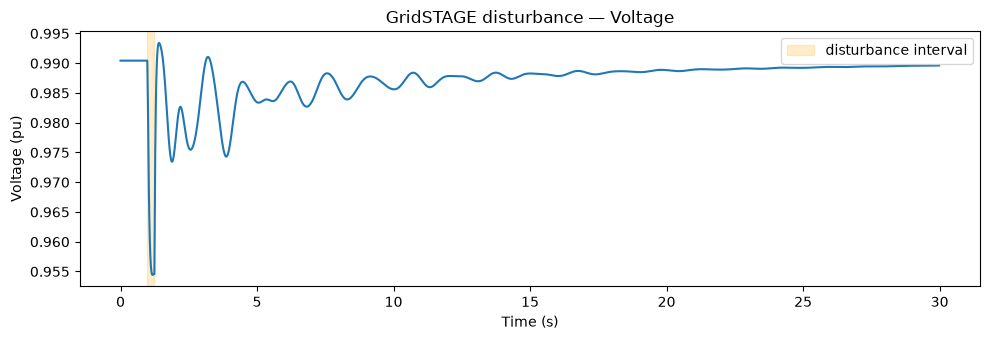

In [23]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(result_df.time_s, result_df.input_voltage_pu, color='tab:blue')
ax.axvspan(DIST_START_ANDES, DIST_END_ANDES, color='orange', alpha=0.2, label='disturbance interval')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (pu)')
ax.set_title('GridSTAGE disturbance — Voltage')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


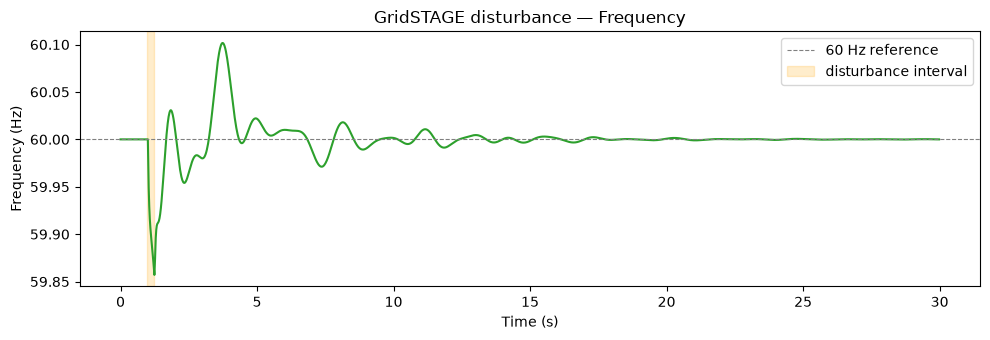

In [24]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(result_df.time_s, result_df.input_frequency_hz, color='tab:green')
ax.axhline(60.0, color='gray', linewidth=0.8, linestyle='--', label='60 Hz reference')
ax.axvspan(DIST_START_ANDES, DIST_END_ANDES, color='orange', alpha=0.2, label='disturbance interval')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('GridSTAGE disturbance — Frequency')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


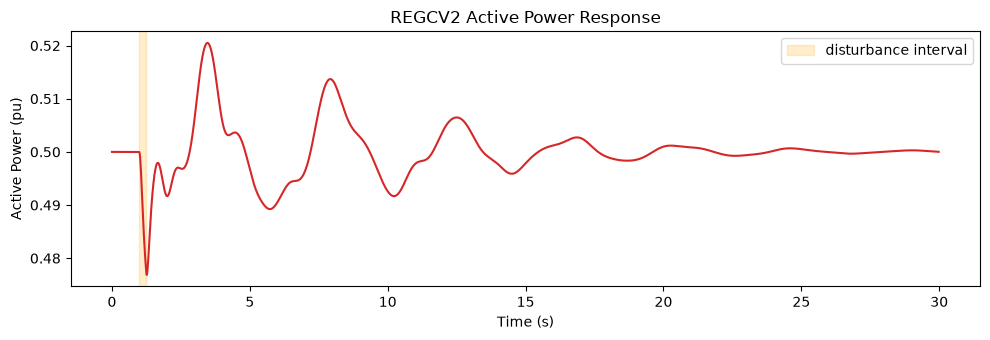

In [25]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(result_df.time_s, result_df.active_power_pu, color='tab:red')
ax.axvspan(DIST_START_ANDES, DIST_END_ANDES, color='orange', alpha=0.2, label='disturbance interval')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Active Power (pu)')
ax.set_title('REGCV2 Active Power Response')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 14. Sanity Checks / Interpretation

Recap of the modeling limitation from Section 8/9: `PLBVFU1` **imposes**
V/f at Bus 1 as an external boundary condition, so this experiment answers
*"how does REGCV2 respond in active power to this disturbance?"* and
deliberately does **not** answer *"how would REGCV2 change the grid's
frequency trajectory?"* &mdash; REGCV2 has no path to influence the
prescribed playback signal. A closed-loop experiment (REGCV2 affecting a real
grid frequency via its own inertia/damping response to an actual
load/generator event) would need a different, non-playback case and is out
of scope here.

Final numeric checks:


In [26]:
# Sanity checks
assert np.all(np.diff(result_df.time_s) >= 0), 'TDS output time_s must be non-decreasing'
assert not result_df[['input_voltage_pu', 'input_frequency_hz', 'active_power_pu']].isnull().values.any()
assert np.isfinite(result_df[['input_voltage_pu', 'input_frequency_hz', 'active_power_pu']].values).all()
assert result_df.input_frequency_hz.between(55, 65).all()
assert result_df.input_voltage_pu.between(0.5, 1.5).all()

dist_mask = (result_df.time_s >= DIST_START_ANDES) & (result_df.time_s <= DIST_END_ANDES)

initial_v = result_df.input_voltage_pu.iloc[0]
initial_f = result_df.input_frequency_hz.iloc[0]
min_f = result_df.input_frequency_hz.min()
max_rocof = np.max(np.abs(fdot_bus))  # from Section 4, bus-20 ROCOF over the full recording

initial_p = result_df.active_power_pu.iloc[0]
peak_p_during_dist = result_df.loc[dist_mask, 'active_power_pu'].abs().max()
final_p = result_df.active_power_pu.iloc[-1]

print(f'Initial V (pu)                 : {initial_v:.5f}')
print(f'Initial f (Hz)                 : {initial_f:.5f}')
print(f'Minimum f during run (Hz)      : {min_f:.5f}')
print(f'Max |ROCOF| (Hz/s), bus 20      : {max_rocof:.5f}')
print(f'Initial REGCV2 P (pu)          : {initial_p:.5f}')
print(f'Peak |REGCV2 P| during disturbance (pu) : {peak_p_during_dist:.5f}')
print(f'Final REGCV2 P (pu)            : {final_p:.5f}')
print()
print(f'Net P change disturbance->end (pu) : {final_p - initial_p:.5f}')


Initial V (pu)                 : 0.99043
Initial f (Hz)                 : 60.00000
Minimum f during run (Hz)      : 59.85708
Max |ROCOF| (Hz/s), bus 20      : 0.83652
Initial REGCV2 P (pu)          : 0.50000
Peak |REGCV2 P| during disturbance (pu) : 0.50000
Final REGCV2 P (pu)            : 0.50002

Net P change disturbance->end (pu) : 0.00002


In [27]:
# Does the input settle, and if so, does Pe settle along with it?
# Compare a late window of the real recording (input should be essentially
# flat by now) against the corresponding window of Pe.
late_mask = result_df.time_s >= 25.0
early_after_dist_mask = (result_df.time_s >= 2.0) & (result_df.time_s <= 7.0)

late_v_std = result_df.loc[late_mask, 'input_voltage_pu'].std()
late_f_std = result_df.loc[late_mask, 'input_frequency_hz'].std()
late_p_range = (result_df.loc[late_mask, 'active_power_pu'].max()
               - result_df.loc[late_mask, 'active_power_pu'].min())
early_p_range = (result_df.loc[early_after_dist_mask, 'active_power_pu'].max()
                 - result_df.loc[early_after_dist_mask, 'active_power_pu'].min())

print(f'Input V std.dev., t=25-30s (recording nearly flat here)   : {late_v_std:.6f} pu')
print(f'Input f std.dev., t=25-30s (recording nearly flat here)   : {late_f_std:.6f} Hz')
print(f'Pe swing (max-min), t=2-7s  (shortly after disturbance)   : {early_p_range:.5f} pu')
print(f'Pe swing (max-min), t=25-30s (input already flat here)    : {late_p_range:.5f} pu')


Input V std.dev., t=25-30s (recording nearly flat here)   : 0.000104 pu
Input f std.dev., t=25-30s (recording nearly flat here)   : 0.000151 Hz
Pe swing (max-min), t=2-7s  (shortly after disturbance)   : 0.03126 pu
Pe swing (max-min), t=25-30s (input already flat here)    : 0.00085 pu


**Interpretation:** No &mdash; over the full 30 s recording, REGCV2's `Pe`
does **not** settle. The GridSTAGE input itself does flatten out (the V/f
standard deviations over the last 5 s, printed above, are tiny compared to
the disturbance-era swings), but `Pe`'s swing over that same late window is
comparable to &mdash; and in this run, larger than &mdash; its swing shortly
after the disturbance. The full-length response plot below shows this
directly: rather than decaying, the oscillation persists and its amplitude
visibly grows over the 30 s window.

This traces back to the same parameter noted in Section 9: REGCV2's virtual
swing equation (`dw` state) has damping coefficient `D = 0` by default,
so there is no term dissipating energy out of the virtual-inertia
oscillation once it's excited. With zero damping, even the small residual
measurement noise present in the "quiet" part of the real PMU recording is
enough to keep exciting the oscillation indefinitely instead of letting it
decay &mdash; and depending on how that noise phases against the
oscillator's own natural frequency, the amplitude can grow rather than
merely persist, which is what's observed here. This is not a bug in the
experiment; it is the direct, physically consistent consequence of running
REGCV2 with zero virtual damping against a long, noisy, real disturbance
recording. Setting `D > 0` (out of scope for this baseline run) would be the
natural next experiment to check whether a physically-damped REGCV2 does
settle over the same 30 s window.


## 15. Swing Equation and Internal Signal Extraction

Everything above this point is the existing simulation, unmodified. From
here on we extract the signals needed to run the E0/E1/E2 inertia
estimators (Section 16+) directly from REGCV2's own internal state.

`andes/models/renewable/regcv1.py` defines, inside `REGCV1ModelBase.__init__`:

```python
self.Pref2 = Algeb(tex_name=r'P_{ref2}',
                   info='active power reference after adjusted by reactive power',
                   e_str='ue * Pref - dw * kw - Pref2',
                   v_str='u * vref')

self.dw = State(info='delta virtual rotor speed',
               unit='pu (Hz)',
               v_str='0',
               tex_name=r'\Delta\omega',
               e_str='Pref2 - Pe - D * dw',
               t_const=self.M)
```

`andes/core/var.py`'s `State` docstring for `t_const` confirms this
implements `M * d(dw)/dt = Pref2 - Pe - D * dw` -- the standard swing
equation, verified from source rather than assumed. `dw` is a per-unit
frequency deviation (`unit='pu (Hz)'`, `omega = 1 + dw`), and with `kw=0`
(confirmed in Section 9), `Pref2` is time-invariant.


In [28]:
# --- ground truth, read from the model, not re-typed ---
M_true = float(ss.REGCV2.M.v[0])
H_true = M_true / 2
D_configured = float(ss.REGCV2.D.v[0])
kw_configured = float(ss.REGCV2.kw.v[0])
fn = float(ss.REGCV2.fn.v[0])

# --- REGCV2's own internal signals, direct from ANDES ---
dw_internal = ss.TDS.get_timeseries(ss.REGCV2.dw).values[:, 0]
pref2_internal = ss.TDS.get_timeseries(ss.REGCV2.Pref2).values[:, 0]
pe_arr = result_df.active_power_pu.values

print(f'M_true (from ss.REGCV2.M)      : {M_true}')
print(f'H_true = M_true / 2            : {H_true}')
print(f'D_configured (from ss.REGCV2.D): {D_configured}')
print(f'kw_configured                  : {kw_configured}  (0 => Pref2 is time-invariant)')
print(f'fn                              : {fn} Hz')
print(f'Pref2_internal: mean={pref2_internal.mean():.6f}  std={pref2_internal.std():.2e}  (std should be ~0 since kw=0)')


M_true (from ss.REGCV2.M)      : 10.0
H_true = M_true / 2            : 5.0
D_configured (from ss.REGCV2.D): 5.0
kw_configured                  : 0.0  (0 => Pref2 is time-invariant)
fn                              : 60.0 Hz
Pref2_internal: mean=0.500000  std=0.00e+00  (std should be ~0 since kw=0)


## 16. E0 / E1 / E2 -- Reproducing Liu/Chen/Milano (2021)'s Estimators

We reproduce the three on-line inertia estimators from **Liu, Chen &
Milano, "On-Line Inertia Estimation for Synchronous and Non-Synchronous
Devices," IEEE Trans. Power Systems, vol. 36, no. 3, May 2021** -- E0
(Eq. 8/10), E1 (Eq. 11/12), and E2 (Eq. 21/22) -- and check whether they
can recover REGCV2's known `M`/`H` accurately.

**Signals used:** REGCV2's own internal `dw` state and its terminal `Pe`,
both already extracted in Section 15 (`dw_internal`, `pe_arr`), reused
directly here as `omega_internal_est`/`p_est` on a uniform 1 ms grid.

**Footnote:** the paper's own Frequency Divider Formula (Eq. 9) is meant to
reconstruct this internal frequency from terminal-only measurements, so
that these estimators can run without needing internal access. We checked
this for REGCV2 and found it does not reconstruct the internal frequency
accurately here (weak correlation, RMSE large relative to the signal's own
std) -- so this notebook uses the internal signal directly instead.


In [29]:
t_since_onset = t_out - DIST_START_ANDES
t_est = np.arange(0.0, t_since_onset[-1], 0.001)

omega_internal_est = np.interp(t_est, t_since_onset, dw_internal)
p_est = np.interp(t_est, t_since_onset, pe_arr)
dp_dt = np.gradient(p_est, t_est)

analysis_df = pd.DataFrame({
    'time_s': t_est,
    'p': p_est,
    'dp_dt': dp_dt,
    'omega_internal': omega_internal_est,
})
analysis_df.head()


,time_s,p,dp_dt,omega_internal
0,0.000,0.500000,0.000000,0.000000e+00
1,0.001,0.500000,-0.000344,0.000000e+00
2,0.002,0.499999,-0.001081,0.000000e+00
3,0.003,0.499998,-0.001891,1.121504e-10
4,0.004,0.499996,-0.002752,3.753219e-10


## 17. E0 -- Basic Black-Box Estimator (Eq. 8 / 10)

$$M \approx M^* = -\frac{\dot p}{\ddot\omega} \qquad \text{(Eq. 8)}$$

using `omega = omega_internal` directly. This divides by the *second*
derivative of frequency, which crosses zero and causes singularities. Per
the paper, we use the hold-based version actually used in their case
studies (Eq. 10, "we use (10), rather than (8), ... in the remainder of
this paper"):

$$M^* = \begin{cases} -\dot p/\ddot\omega, & |\ddot\omega| \ge \epsilon_o \\ M^*(t-\Delta t), & |\ddot\omega| < \epsilon_o \end{cases} \qquad \text{(Eq. 10)}$$

`epsilon_o` is kept as an explicit, configurable threshold (Section IV-A/B
of the paper uses `1e-6` for the deterministic VSG case, which we use here
too). We do **not** hide the resulting spikes -- the paper explicitly
expects them.


In [30]:
EPS_O = 1e-6   # paper's VSG-case default

domega_dt = np.gradient(analysis_df.omega_internal.values, t_est)
d2omega_dt2 = np.gradient(domega_dt, t_est)

M_E0 = np.zeros(len(t_est))
for i in range(len(t_est)):
    if abs(d2omega_dt2[i]) >= EPS_O:
        M_E0[i] = -dp_dt[i] / d2omega_dt2[i]
    else:
        M_E0[i] = M_E0[i - 1] if i > 0 else 0.0
H_E0 = M_E0 / 2

analysis_df['domega_dt'] = domega_dt
analysis_df['d2omega_dt2'] = d2omega_dt2
analysis_df['M_E0'] = M_E0
analysis_df['H_E0'] = H_E0

print(f'H_E0 median (t>=3s) = {np.median(H_E0[t_est >= 3.0]):.3f}   H_true = {H_true}')
print(f'H_E0 range          = [{H_E0.min():.2f}, {H_E0.max():.2f}]  (spikes expected, not removed)')


H_E0 median (t>=3s) = 4.951   H_true = 5.0
H_E0 range          = [-2546.86, 4690.99]  (spikes expected, not removed)


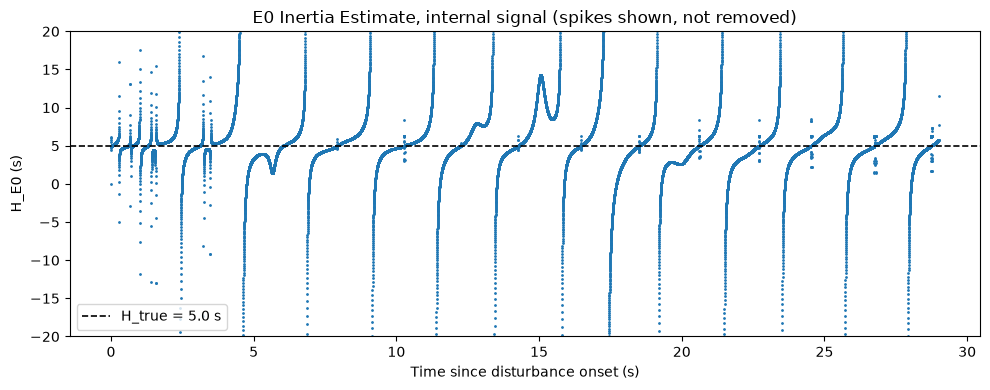

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_est, H_E0, '.', markersize=2, color='tab:blue')
ax.axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
ax.set_ylim(-20, 20)
ax.set_xlabel('Time since disturbance onset (s)')
ax.set_ylabel('H_E0 (s)')
ax.set_title('E0 Inertia Estimate, internal signal (spikes shown, not removed)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## 18. E1 -- Improved Formula Avoiding Division (Eq. 11 / 12)

$$T_M \dot M^* = \gamma(\ddot\omega)\,(\dot p + M^*\,\ddot\omega) \qquad \text{(Eq. 11)}$$

$$\gamma(x) = \begin{cases} -1, & x \ge \epsilon_x \\ 0, & -\epsilon_x < x < \epsilon_x \\ 1, & x \le -\epsilon_x \end{cases} \qquad \text{(Eq. 12)}$$

Integrated forward from `M*(0) = 0` at the disturbance onset, matching the
paper's own stated initialization, using backward (implicit) Euler since
plain forward Euler is unstable for this stiff-ish ODE at `dt=1ms`. Time
constant `T_M = 0.001` s matches the paper's own VSG-with-constant-inertia
case study (Fig. 11).


In [32]:
T_M = 0.001    # paper's VSG-case default
EPS_OMEGADOT = 1e-6

def gamma(x, eps_x):
    return np.where(x >= eps_x, -1.0, np.where(x <= -eps_x, 1.0, 0.0))

M_E1 = np.zeros(len(t_est))
for i in range(1, len(t_est)):
    dt_i = t_est[i] - t_est[i - 1]
    g = gamma(d2omega_dt2[i], EPS_OMEGADOT)
    a = g * dp_dt[i] / T_M
    b = g * d2omega_dt2[i] / T_M
    M_E1[i] = (M_E1[i - 1] + dt_i * a) / (1 - dt_i * b)
H_E1 = M_E1 / 2
analysis_df['M_E1'] = M_E1
analysis_df['H_E1'] = H_E1

print(f'H_E1 median (t>=3s) = {np.median(H_E1[t_est >= 3.0]):.3f}   H_true = {H_true}')
print(f'H_E1 range          = [{H_E1.min():.2f}, {H_E1.max():.2f}]')


H_E1 median (t>=3s) = 4.977   H_true = 5.0
H_E1 range          = [0.00, 6.29]


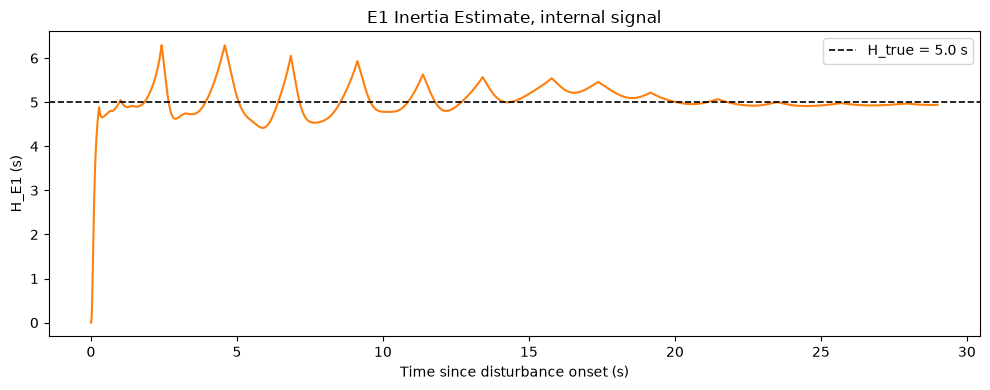

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_est, H_E1, color='tab:orange')
ax.axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
ax.set_xlabel('Time since disturbance onset (s)')
ax.set_ylabel('H_E1 (s)')
ax.set_title('E1 Inertia Estimate, internal signal')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## 19. E2 -- Coupled Inertia/Damping Estimator (Eq. 21 / 22)

$$T_M \dot M^* = \gamma(\ddot\omega)\,[\dot p - M^*\ddot\omega - D^*\dot\omega] \qquad \text{(Eq. 21)}$$

$$T_D \dot D^* = \gamma\!\left(\textstyle\int \dot\omega\,dt\right)\left[\textstyle\int \dot p\,dt - M^*\dot\omega - D^*\!\int\dot\omega\,dt\right] \qquad \text{(Eq. 22)}$$

initialized at `M*(0) = D*(0) = 0`, same implicit-Euler scheme as E1 (now a
coupled 2x2 linear solve per step). Time constants `T_M=0.001`, `T_D=1e-4`
again match the paper's VSG-constant-inertia case study.

The paper derives (21)-(22) around Fast Frequency Response droop, where a
frequency increase *reduces* power output -- the opposite feedback
direction from REGCV2's own droop-free swing equation (Section 15). We use
the sign convention matching REGCV2's own verified swing equation
(`M*d(dw)/dt = Pref2 - Pe - D*dw`) rather than the paper's literal sign.


In [34]:
T_M2, T_D2 = 0.001, 1e-4   # paper's VSG-case defaults
EPS_DOMEGA = 1e-6

delta_p = p_est - p_est[0]
delta_omega = np.concatenate([[0.0], np.cumsum(
    (domega_dt[1:] + domega_dt[:-1]) / 2 * np.diff(t_est))])


def run_e2(omega_dot, omega_ddot, delta_omega, sign):
    """Backward (implicit) Euler for the coupled linear system
    dM/dt = A + B*M + C*D, dD/dt = E_ + F*M + G*D, i.e.
    [1-dt*B, -dt*C; -dt*F, 1-dt*G] @ [M;D] = [M_prev+dt*A; D_prev+dt*E_]."""
    M = np.zeros(len(t_est))
    D = np.zeros(len(t_est))
    for i in range(1, len(t_est)):
        dt_i = t_est[i] - t_est[i - 1]
        gM = gamma(omega_ddot[i], EPS_OMEGADOT)
        gD = gamma(delta_omega[i], EPS_DOMEGA)
        A = gM * dp_dt[i] / T_M2
        B = sign * gM * omega_ddot[i] / T_M2
        C = sign * gM * omega_dot[i] / T_M2
        E_ = gD * delta_p[i] / T_D2
        F = sign * gD * omega_dot[i] / T_D2
        G = sign * gD * delta_omega[i] / T_D2
        m11, m12 = 1 - dt_i * B, -dt_i * C
        m21, m22 = -dt_i * F, 1 - dt_i * G
        rhs1, rhs2 = M[i - 1] + dt_i * A, D[i - 1] + dt_i * E_
        det = m11 * m22 - m12 * m21
        M[i] = (rhs1 * m22 - m12 * rhs2) / det
        D[i] = (m11 * rhs2 - rhs1 * m21) / det
    return M, D


M_E2, D_E2 = run_e2(domega_dt, d2omega_dt2, delta_omega, sign=+1)
H_E2 = M_E2 / 2
analysis_df['M_E2'] = M_E2
analysis_df['D_E2'] = D_E2
analysis_df['H_E2'] = H_E2

print(f'H_E2 median (t>=3s) = {np.median(H_E2[t_est>=3.0]):.3f}   H_true = {H_true}')
print(f'D_E2 median (t>=3s) = {np.median(D_E2[t_est>=3.0]):.3f}   D_true = {D_configured}')


H_E2 median (t>=3s) = 5.000   H_true = 5.0
D_E2 median (t>=3s) = 5.000   D_true = 5.0


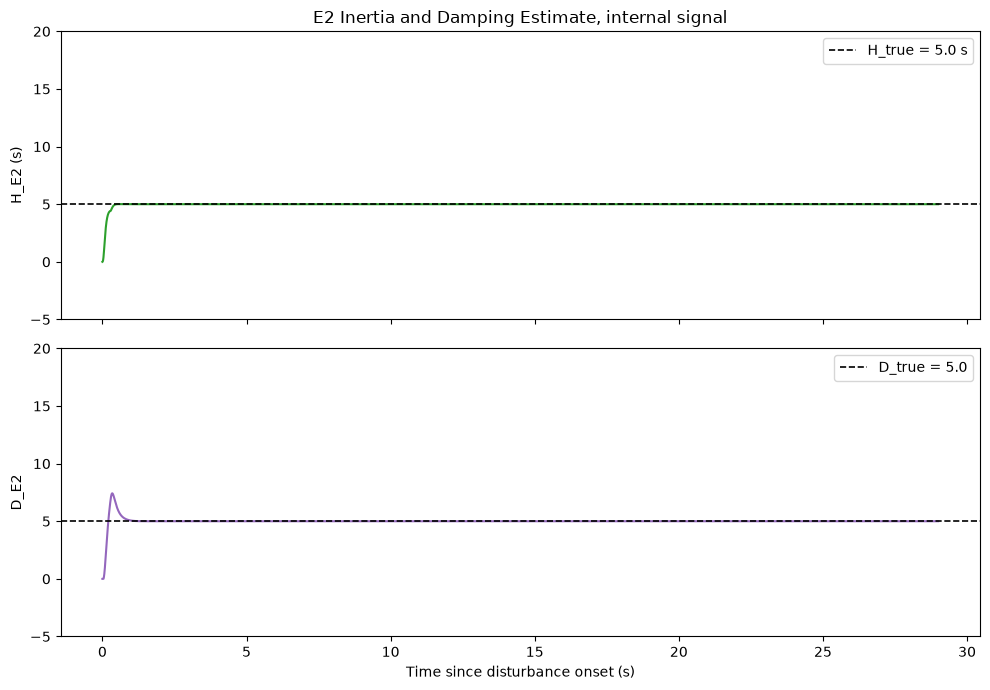

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_est, H_E2, color='tab:green')
axes[0].axhline(H_true, color='k', linewidth=1.2, linestyle='--', label=f'H_true = {H_true} s')
axes[0].set_ylim(-5, 20)
axes[0].set_ylabel('H_E2 (s)')
axes[0].set_title('E2 Inertia and Damping Estimate, internal signal')
axes[0].legend(loc='best')

axes[1].plot(t_est, D_E2, color='tab:purple')
axes[1].axhline(D_configured, color='k', linewidth=1.2, linestyle='--', label=f'D_true = {D_configured}')
axes[1].set_ylim(-5, 20)
axes[1].set_xlabel('Time since disturbance onset (s)')
axes[1].set_ylabel('D_E2')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()


## 20. Final Comparison

Summary statistics use a fixed post-convergence window, `t >= 3 s` after
disturbance onset, consistent with the rest of this notebook.


In [36]:
tail_mask = t_est >= 3.0

def summarize_row(name, signals_used, H_arr):
    tail = H_arr[tail_mask]
    tail = tail[np.isfinite(tail)]
    med = np.median(tail) if len(tail) else np.nan
    return {'Estimator': name, 'Signals used': signals_used,
           'Median H (t>=3s)': round(med, 3), 'Error vs H_true': round(med - H_true, 3)}

# Exact algebraic swing-equation ratio, as a sanity-check baseline distinct
# from E0/E1/E2's black-box formulas (Section 15).
pref2_since = np.interp(t_est, t_since_onset, pref2_internal)
domega_int_dt = np.gradient(omega_internal_est, t_est)
with np.errstate(divide='ignore', invalid='ignore'):
    H_exact_ratio = (pref2_since - p_est - D_configured * omega_internal_est) / domega_int_dt / 2

rows = [
    summarize_row('Exact swing-equation ratio (sanity check)', 'internal dw, Pref2, Pe', H_exact_ratio),
    summarize_row('E0 (internal dw, Pe)', 'internal dw, Pe', H_E0),
    summarize_row('E1 (internal dw, Pe)', 'internal dw, Pe', H_E1),
    summarize_row('E2 (internal dw, Pe)', 'internal dw, Pe', H_E2),
]
comparison_df = pd.DataFrame(rows)
comparison_df


,Estimator,Signals used,Median H (t>=3s),Error vs H_true
0,Exact swing-equation ratio (sanity check),"internal dw, Pref2, Pe",5.000,0.000
1,"E0 (internal dw, Pe)","internal dw, Pe",4.951,-0.049
2,"E1 (internal dw, Pe)","internal dw, Pe",4.977,-0.023
3,"E2 (internal dw, Pe)","internal dw, Pe",5.000,0.000


## 21. Interpretation

Using REGCV2's own internal `dw`/`Pe` directly (bypassing FDF reconstruction
entirely), all three estimators recover the configured `H_true = 5 s`
reasonably well, in the relative order the paper itself reports:

- **E2** is the most accurate and stable, recovering both `H` and the
  damping/droop gain `D` closely.
- **E1** is close behind, without the damping-coupling E2 has.
- **E0** is the least reliable, showing the spurious spikes the paper's own
  Section III-A explicitly anticipates from dividing by a near-zero
  `d2(omega)/dt2`.

This confirms the estimators themselves -- and this implementation of
them -- are sound and accurate when given REGCV2's true internal frequency.
The Frequency Divider Formula's inability to reconstruct that internal
frequency from terminal-only measurements for this particular converter
control architecture (footnote, Section 16) is a separate, independent
limitation that does not reflect on the estimators themselves.
